# Dataset Visualization — Atlas Raman

A visual tour of every file in `Atlas Data/`. For each `.xls`/`.txt` file we
generate four diagnostic plots; summary plots come at the end.

**Per-file plots** (saved to `images/<class>/[<subclass>/]<file_id>/`):

| File | What it shows |
|---|---|
| `01_overlay.png` | All pixel spectra overlaid (faint blue) + mean (red) |
| `02_heatmap.png` | 2D heatmap, rows = pixels (sorted), x = wavenumber |
| `03_spatial.png` | The physical x/y scan colored by total per-pixel intensity |
| `04_mean_band.png` | Mean ± 5/95-percentile band, raw vs preprocessed |

**Summary plots** (saved to `images/_summary/`):
file/spectra counts, class & subclass mean spectra, PCA scatter, inter-file
cosine-similarity heatmap.

Data source: the `data_cache/` parquet+npy bundle built by `scripts/build_dataset.py`
(pixel-capped at 200 per file, same data the models train on).


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from atlas.io import load_cache

CACHE = REPO_ROOT / "data_cache"
IMAGES = REPO_ROOT / "images"
SUMMARY = IMAGES / "_summary"
IMAGES.mkdir(exist_ok=True)
SUMMARY.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"

CLASS_COLORS = {
    "STEC":       "#d62728",
    "Non-STEC":   "#1f77b4",
    "Salmonella": "#2ca02c",
    "H2O":        "#7f7f7f",
}
SUBCLASS_COLORS = {
    "O103H2":   "#d62728", "O121H19":  "#e7665a", "O157H7":   "#a02124",
    "83972":      "#1f77b4", "ATCC25922":  "#5fa6d8", "K-12":       "#114573",
    "Dublin":      "#2ca02c", "Heidelburg":  "#73c073", "Typhimurium": "#175f17",
    None: "#7f7f7f",
}
CLASS_ORDER = ["STEC", "Non-STEC", "Salmonella", "H2O"]


## Load cached data

`X_raw` is interpolated to a 2048-bin canonical wavenumber axis (76–3499 cm⁻¹).
`X_proc` is the same spectra after cosmic-ray removal → arPLS baseline → SG smoothing
→ crop to fingerprint+CH regions (987 bins, ~400–3049 cm⁻¹) → SNV.


In [2]:
spec_df, X_raw, wn_raw, meta = load_cache(CACHE)
X_proc = np.load(CACHE / "spectra_array_preprocessed.npy")
wn_proc = np.load(CACHE / "wavenumber_axis_preprocessed.npy")

print(f"raw spectra   : {X_raw.shape}   wn=[{wn_raw[0]:.1f}, {wn_raw[-1]:.1f}]")
print(f"proc spectra  : {X_proc.shape}  wn=[{wn_proc[0]:.1f}, {wn_proc[-1]:.1f}]")
print(f"metadata files: {len(meta)}")
print(f"classes       : {meta['primary_class'].value_counts().to_dict()}")
print()
# Reset spec_df index so we can index X_raw/X_proc by row position.
spec_df = spec_df.reset_index(drop=True)


raw spectra   : (7999, 2048)   wn=[76.0, 3499.0]
proc spectra  : (7999, 987)  wn=[400.4, 3049.2]
metadata files: 87
classes       : {'STEC': 27, 'Salmonella': 27, 'Non-STEC': 25, 'H2O': 8}



## Per-file plotting function

`plot_file(file_id, dest_dir)` produces the four PNGs for a single file inside
`dest_dir`. We'll demo it on one file (output shown inline), then loop over all 87.


In [3]:
def _band(ax, wn, X, color, label_prefix):
    mu = X.mean(0)
    p5 = np.percentile(X, 5, axis=0)
    p95 = np.percentile(X, 95, axis=0)
    ax.fill_between(wn, p5, p95, alpha=0.22, color=color, label=f"{label_prefix} p5–p95")
    ax.plot(wn, mu, color=color, lw=1.3, label=f"{label_prefix} mean")


def plot_file(file_id: str, dest_dir: Path, *, show: bool = False):
    # Save 4 PNGs for one file. Set show=True to also display inline.
    rows = spec_df[spec_df["file_id"] == file_id]
    if rows.empty:
        return
    idx = rows.index.to_numpy()
    raw = X_raw[idx]
    proc = X_proc[idx]
    x_um = rows["x_um"].to_numpy()
    y_um = rows["y_um"].to_numpy()

    rec = meta[meta["file_id"] == file_id].iloc[0]
    pc = rec["primary_class"]
    sc = rec["subclass"] if pd.notna(rec["subclass"]) else None
    sc_label = sc if sc else "—"
    grid_str = f"{int(rec['grid_nx'])}×{int(rec['grid_ny'])}"
    n_px = len(raw)
    title_tag = f"{file_id}  •  {pc}/{sc_label}  •  {n_px} px  •  grid {grid_str}"

    dest_dir.mkdir(parents=True, exist_ok=True)

    # ----- 1. overlay -----
    fig, ax = plt.subplots(figsize=(11, 4.5))
    for s in raw:
        ax.plot(wn_raw, s, color="steelblue", alpha=0.06, lw=0.5)
    ax.plot(wn_raw, raw.mean(0), color="crimson", lw=1.4, label="mean")
    ax.set_xlabel("Wavenumber (cm⁻¹)")
    ax.set_ylabel("Intensity (raw counts)")
    ax.set_title(f"All pixel spectra (raw)  —  {title_tag}")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(dest_dir / "01_overlay.png", bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)

    # ----- 2. heatmap -----
    order = np.argsort(raw.sum(axis=1))
    fig, ax = plt.subplots(figsize=(11, 5))
    im = ax.imshow(
        raw[order],
        aspect="auto",
        cmap="viridis",
        extent=[wn_raw[0], wn_raw[-1], 0, len(raw)],
        origin="lower",
    )
    ax.set_xlabel("Wavenumber (cm⁻¹)")
    ax.set_ylabel("Pixel index (sorted by total intensity)")
    ax.set_title(f"Pixel × wavenumber heatmap (raw)  —  {title_tag}")
    plt.colorbar(im, ax=ax, label="intensity (raw)")
    plt.tight_layout()
    fig.savefig(dest_dir / "02_heatmap.png", bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)

    # ----- 3. spatial map -----
    tot = raw.sum(axis=1)
    fig, ax = plt.subplots(figsize=(7, 6))
    sc_pl = ax.scatter(x_um, y_um, c=tot, cmap="viridis", s=28, marker="s",
                       edgecolors="none")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title(f"Spatial scan map  —  {title_tag}")
    ax.set_aspect("equal", adjustable="datalim")
    plt.colorbar(sc_pl, ax=ax, label="∑ intensity (raw, all wn)")
    plt.tight_layout()
    fig.savefig(dest_dir / "03_spatial.png", bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)

    # ----- 4. mean ± p5/p95 band, raw vs preprocessed -----
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
    _band(axes[0], wn_raw, raw, "steelblue", "raw")
    axes[0].set_xlabel("Wavenumber (cm⁻¹)")
    axes[0].set_ylabel("Intensity (raw counts)")
    axes[0].set_title("Raw")
    axes[0].legend(loc="upper right")
    axes[0].grid(alpha=0.3)

    _band(axes[1], wn_proc, proc, "darkgreen", "proc")
    axes[1].set_xlabel("Wavenumber (cm⁻¹)")
    axes[1].set_ylabel("SNV intensity (post baseline+SG)")
    axes[1].set_title("Preprocessed (arPLS → SG → crop → SNV)")
    axes[1].legend(loc="upper right")
    axes[1].grid(alpha=0.3)

    fig.suptitle(title_tag, y=1.03)
    plt.tight_layout()
    fig.savefig(dest_dir / "04_mean_band.png", bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


def dest_for_file(file_id: str) -> Path:
    # Mirror the dataset layout.
    # Atlas Data/STEC/O157H7/R501_*.xls -> images/STEC/O157H7/R501_*/
    rec = meta[meta["file_id"] == file_id].iloc[0]
    rel = Path(rec["file_path"])           # e.g. STEC/O157H7/R501_*.xls
    return IMAGES / rel.parent / rel.stem  # images/STEC/O157H7/R501_*/


### Demo: one file shown inline

Picking the first file in each class for a visual sanity check. The remaining
files run silently in the next cell.

Demo files (one per class): ['R358_100_10000ms_260226', 'R357_100_10000ms_260226', 'R365_100_10000ms_260227', 'R372_100_10000ms_260306']



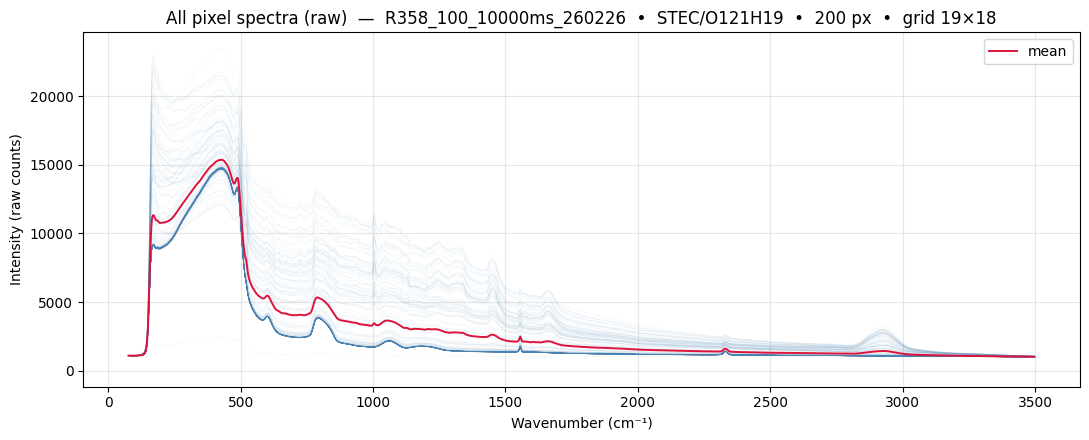

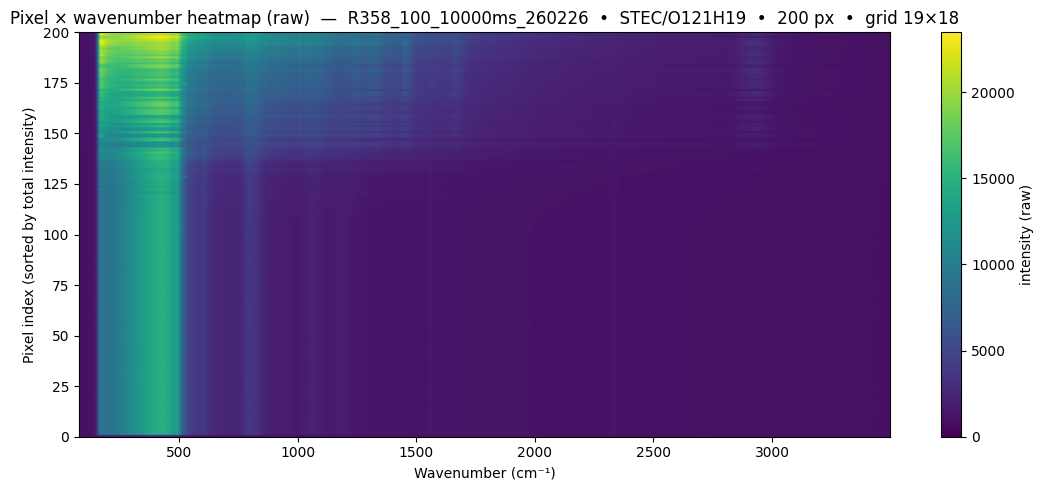

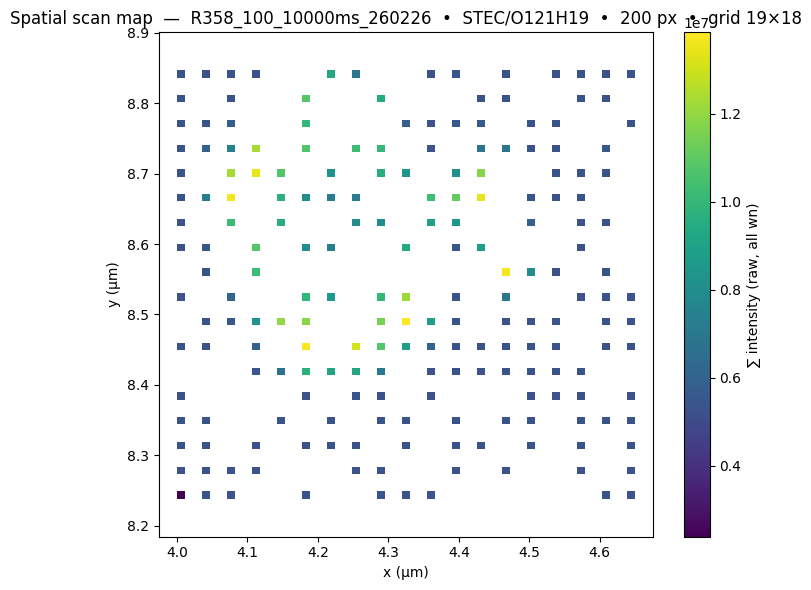

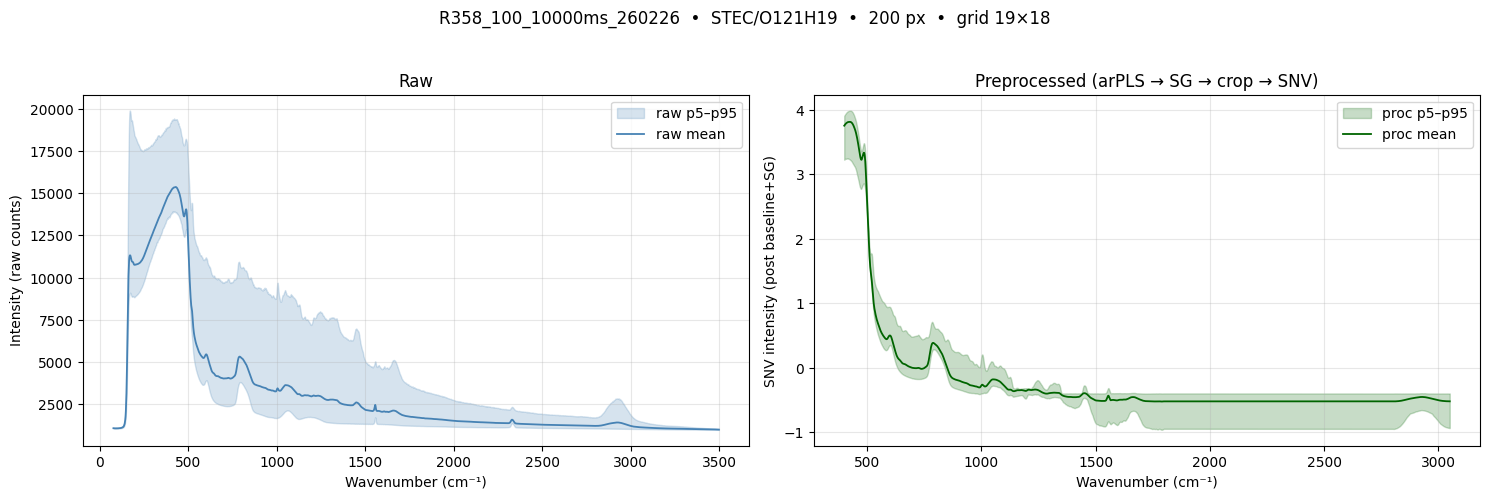

In [4]:
demo_ids = []
for c in CLASS_ORDER:
    sub_meta = meta[meta["primary_class"] == c].sort_values("file_id")
    if len(sub_meta) > 0:
        demo_ids.append(sub_meta.iloc[0]["file_id"])

print("Demo files (one per class):", demo_ids)
print()

# Display the first demo file inline (4 plots).
plot_file(demo_ids[0], dest_for_file(demo_ids[0]), show=True)


## Generate plots for every file

86 + 1 files, 4 plots each = 348 PNGs. ~30s on a laptop.

In [5]:
file_ids = meta["file_id"].tolist()
for fid in tqdm(file_ids, desc="files"):
    plot_file(fid, dest_for_file(fid), show=False)

print(f"\nSaved per-file plots for {len(file_ids)} files under {IMAGES}")


files:   0%|          | 0/87 [00:00<?, ?it/s]

files:   1%|          | 1/87 [00:00<00:54,  1.58it/s]

files:   2%|▏         | 2/87 [00:01<00:47,  1.77it/s]

files:   3%|▎         | 3/87 [00:01<00:43,  1.92it/s]

files:   5%|▍         | 4/87 [00:02<00:41,  1.99it/s]

...

files:  98%|█████████▊| 85/87 [00:43<00:00,  2.01it/s]

files:  99%|█████████▉| 86/87 [00:44<00:00,  2.01it/s]

files: 100%|██████████| 87/87 [00:44<00:00,  2.01it/s]

files: 100%|██████████| 87/87 [00:44<00:00,  1.95it/s]


Saved per-file plots for 87 files under /Users/devashishthapliyal/Documents/NomadX/images


## Summary plots

Dataset-level views: inventory, class means (raw + preprocessed), subclass means,
PCA scatter, and inter-file cosine similarity. These land in `images/_summary/`.

### 1. Inventory — files & spectra per class/subclass

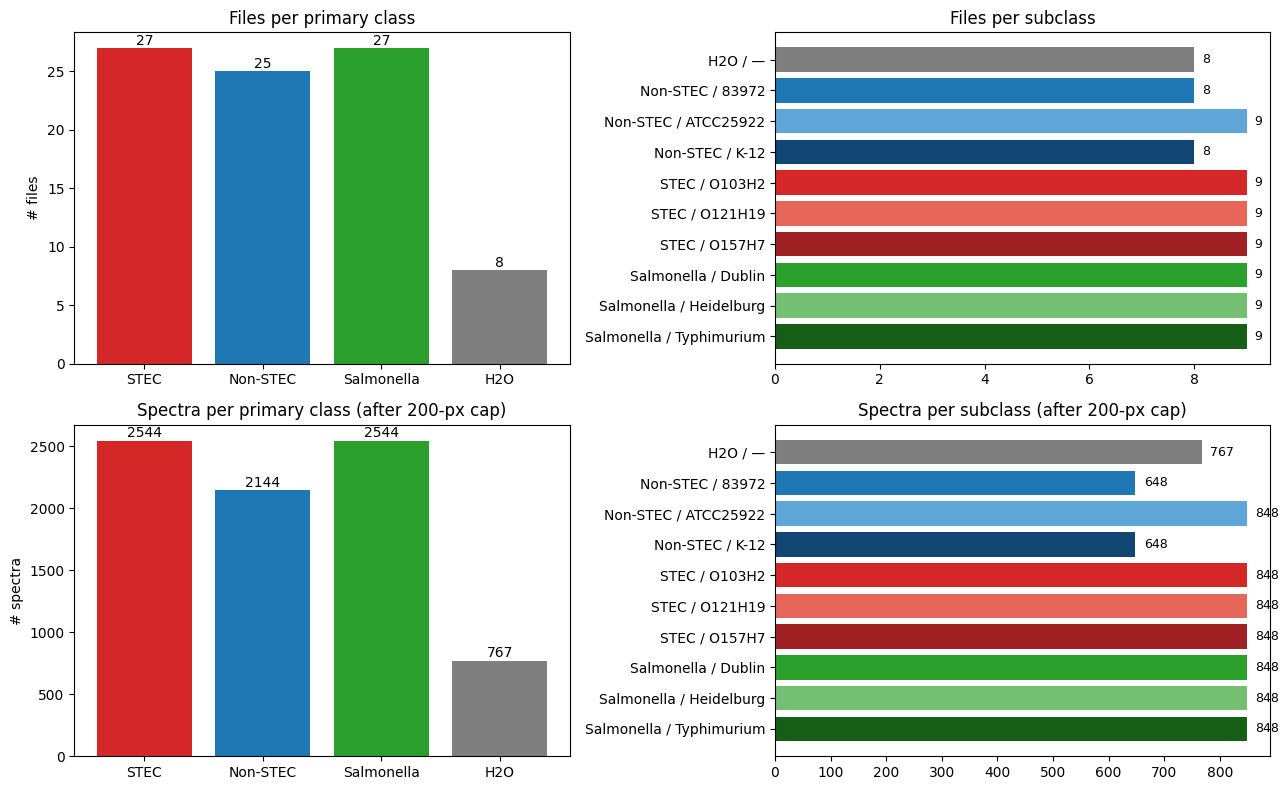

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

counts = meta["primary_class"].value_counts().reindex(CLASS_ORDER)
axes[0, 0].bar(counts.index, counts.values,
               color=[CLASS_COLORS[c] for c in counts.index])
axes[0, 0].set_title("Files per primary class")
axes[0, 0].set_ylabel("# files")
for i, v in enumerate(counts.values):
    axes[0, 0].text(i, v + 0.3, str(v), ha="center", fontsize=10)

sub_counts = (
    meta.assign(label=lambda d: d["primary_class"] + " / " + d["subclass"].fillna("—"))
    ["label"].value_counts().sort_index()
)
sub_colors = [SUBCLASS_COLORS.get(
    lbl.split(" / ")[1] if " / " in lbl and lbl.split(" / ")[1] != "—" else None,
    "#7f7f7f") for lbl in sub_counts.index]
axes[0, 1].barh(sub_counts.index, sub_counts.values, color=sub_colors)
axes[0, 1].set_title("Files per subclass")
axes[0, 1].invert_yaxis()
for i, v in enumerate(sub_counts.values):
    axes[0, 1].text(v + 0.15, i, str(v), va="center", fontsize=9)

px_class = spec_df["primary_class"].value_counts().reindex(CLASS_ORDER)
axes[1, 0].bar(px_class.index, px_class.values,
               color=[CLASS_COLORS[c] for c in px_class.index])
axes[1, 0].set_title("Spectra per primary class (after 200-px cap)")
axes[1, 0].set_ylabel("# spectra")
for i, v in enumerate(px_class.values):
    axes[1, 0].text(i, v + 30, str(v), ha="center", fontsize=10)

spec_lbl = spec_df.assign(
    label=lambda d: d["primary_class"] + " / " + d["subclass"].fillna("—")
)
px_sub = spec_lbl["label"].value_counts().sort_index()
sub_colors2 = [SUBCLASS_COLORS.get(
    lbl.split(" / ")[1] if " / " in lbl and lbl.split(" / ")[1] != "—" else None,
    "#7f7f7f") for lbl in px_sub.index]
axes[1, 1].barh(px_sub.index, px_sub.values, color=sub_colors2)
axes[1, 1].set_title("Spectra per subclass (after 200-px cap)")
axes[1, 1].invert_yaxis()
for i, v in enumerate(px_sub.values):
    axes[1, 1].text(v + 15, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.savefig(SUMMARY / "01_inventory.png", bbox_inches="tight")
plt.show()


### 2. Class mean spectra — raw vs preprocessed

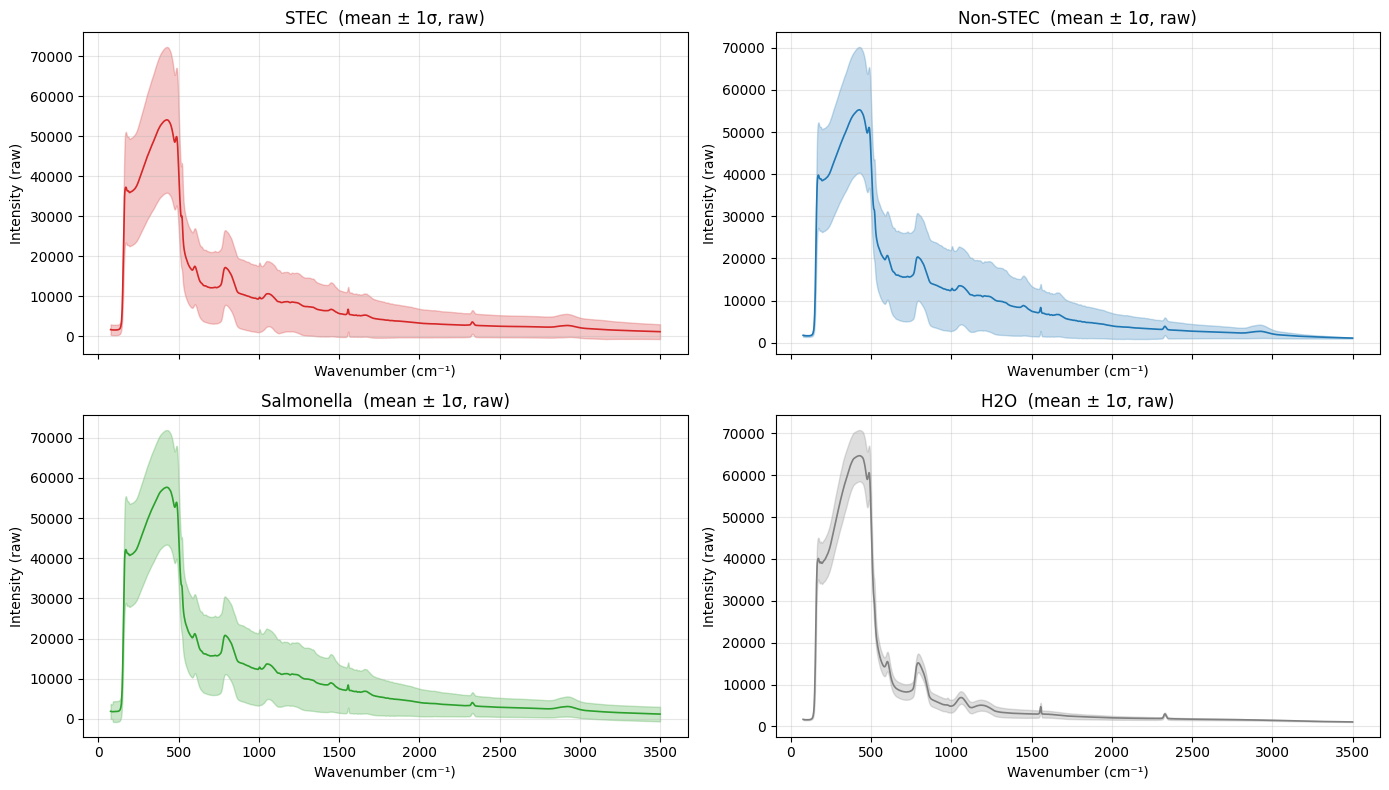

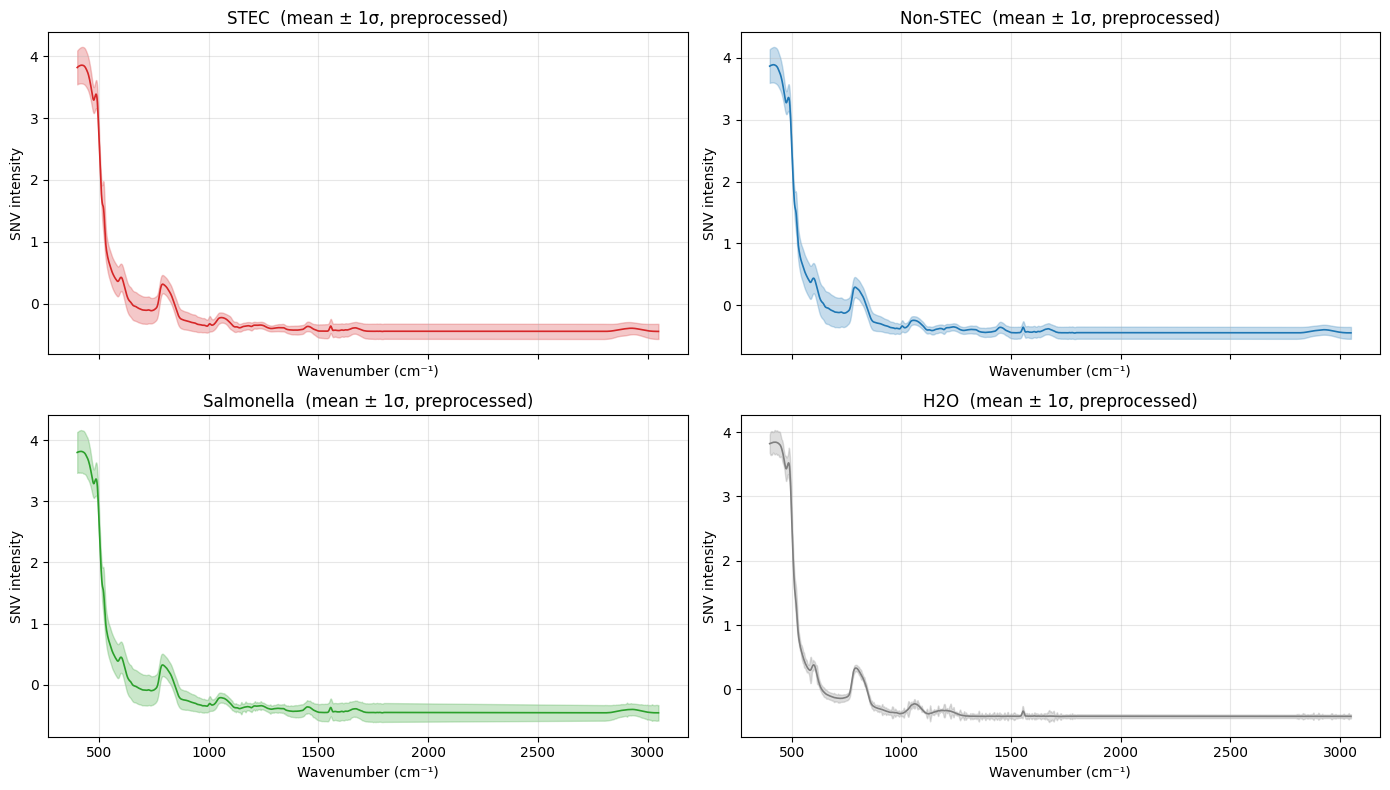

In [7]:
def mean_std(X, labels):
    return {c: (X[labels == c].mean(0), X[labels == c].std(0)) for c in CLASS_ORDER}

labels_c = spec_df["primary_class"].values

# Raw
stats_raw = mean_std(X_raw, labels_c)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, c in zip(axes.flat, CLASS_ORDER):
    mu, sd = stats_raw[c]
    ax.fill_between(wn_raw, mu - sd, mu + sd, alpha=0.25, color=CLASS_COLORS[c])
    ax.plot(wn_raw, mu, color=CLASS_COLORS[c], lw=1.2)
    ax.set_title(f"{c}  (mean ± 1σ, raw)")
    ax.set_xlabel("Wavenumber (cm⁻¹)")
    ax.set_ylabel("Intensity (raw)")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(SUMMARY / "02_class_means_raw.png", bbox_inches="tight")
plt.show()

# Preprocessed
stats_proc = mean_std(X_proc, labels_c)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, c in zip(axes.flat, CLASS_ORDER):
    mu, sd = stats_proc[c]
    ax.fill_between(wn_proc, mu - sd, mu + sd, alpha=0.25, color=CLASS_COLORS[c])
    ax.plot(wn_proc, mu, color=CLASS_COLORS[c], lw=1.2)
    ax.set_title(f"{c}  (mean ± 1σ, preprocessed)")
    ax.set_xlabel("Wavenumber (cm⁻¹)")
    ax.set_ylabel("SNV intensity")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(SUMMARY / "03_class_means_processed.png", bbox_inches="tight")
plt.show()


### 3. Subclass means — one panel per parent class

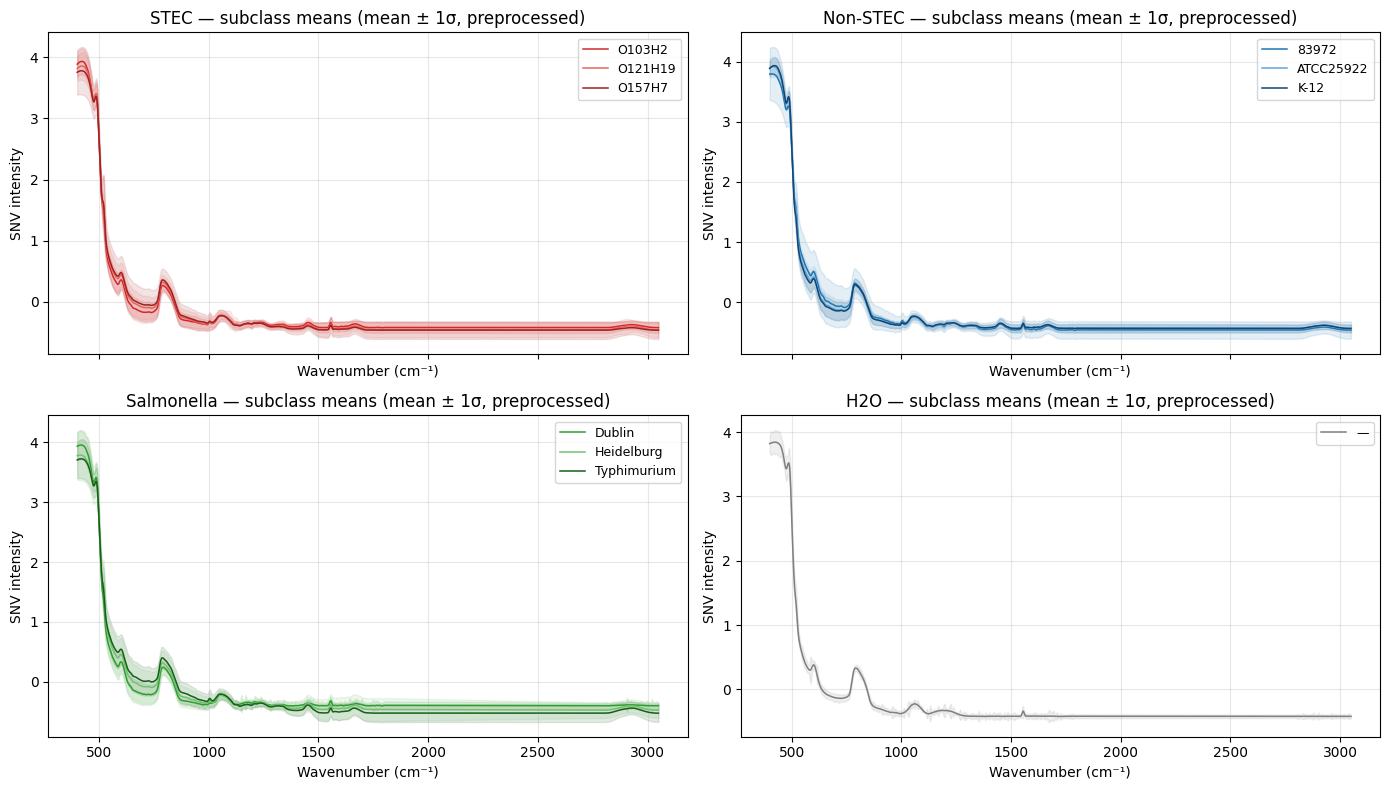

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, parent in zip(axes.flat, CLASS_ORDER):
    sub_in_parent = sorted({
        sc for pc, sc in zip(spec_df["primary_class"], spec_df["subclass"].fillna("—"))
        if pc == parent
    })
    for sc in sub_in_parent:
        m = (spec_df["primary_class"].values == parent)
        if sc != "—":
            m = m & (spec_df["subclass"].fillna("—").values == sc)
        mu = X_proc[m].mean(0)
        sd = X_proc[m].std(0)
        color = SUBCLASS_COLORS.get(sc if sc != "—" else None, "#888")
        ax.plot(wn_proc, mu, color=color, lw=1.1, label=sc)
        ax.fill_between(wn_proc, mu - sd, mu + sd, color=color, alpha=0.12)
    ax.set_title(f"{parent} — subclass means (mean ± 1σ, preprocessed)")
    ax.set_xlabel("Wavenumber (cm⁻¹)")
    ax.set_ylabel("SNV intensity")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(SUMMARY / "04_subclass_means.png", bbox_inches="tight")
plt.show()


### 4. PCA scatter — colored by class and subclass

PC1–PC5 var explained: [0.671 0.141 0.064 0.037 0.016]


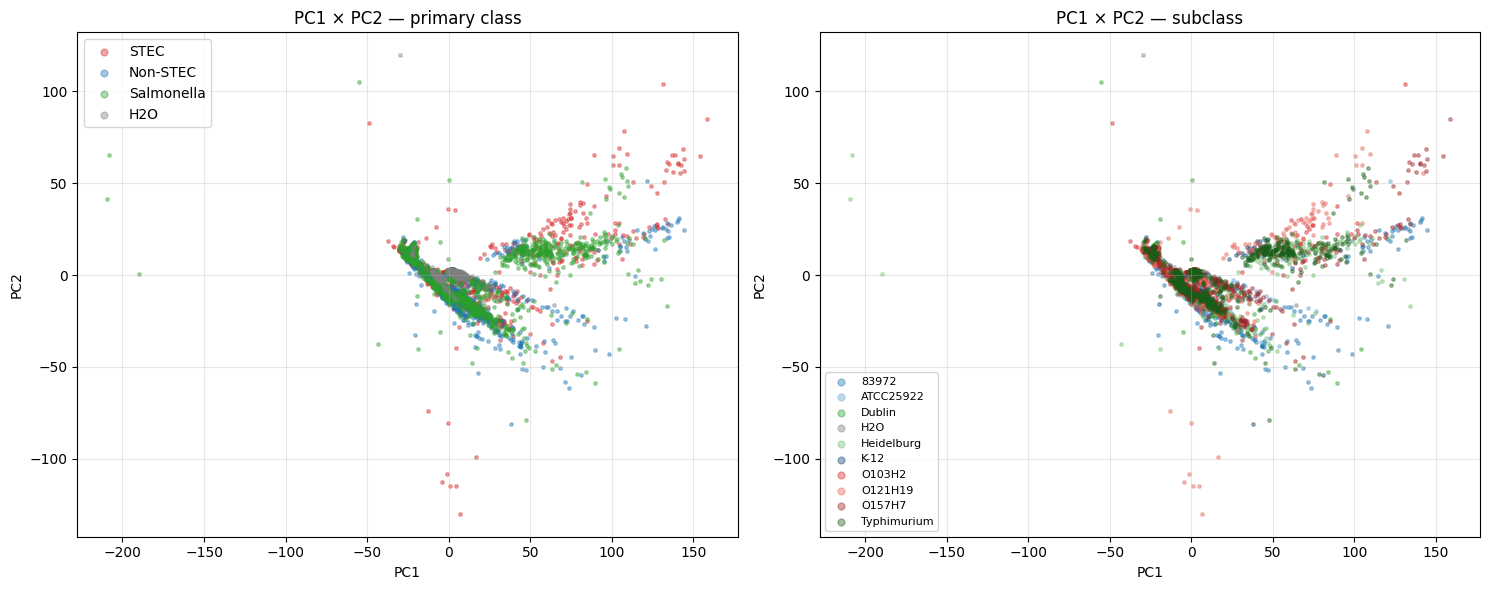

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Xs = StandardScaler().fit_transform(X_proc)
pca = PCA(n_components=10, random_state=0).fit(Xs)
Z = pca.transform(Xs)
print(f"PC1–PC5 var explained: {np.round(pca.explained_variance_ratio_[:5], 3)}")

labels_sub = spec_df["subclass"].fillna("H2O").values
sub_palette = {**SUBCLASS_COLORS, "H2O": "#7f7f7f"}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for c in CLASS_ORDER:
    m = labels_c == c
    axes[0].scatter(Z[m, 0], Z[m, 1], s=6, alpha=0.4,
                    color=CLASS_COLORS[c], label=c)
axes[0].set_title("PC1 × PC2 — primary class")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(markerscale=2); axes[0].grid(alpha=0.3)

for sc in sorted(set(labels_sub)):
    m = labels_sub == sc
    axes[1].scatter(Z[m, 0], Z[m, 1], s=6, alpha=0.4,
                    color=sub_palette.get(sc, "#888"), label=sc)
axes[1].set_title("PC1 × PC2 — subclass")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].legend(markerscale=2, fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SUMMARY / "05_pca_scatter.png", bbox_inches="tight")
plt.show()


### 5. Inter-file cosine similarity

For every pair of files we compute cosine similarity between their mean
preprocessed spectra, sorted by (class, subclass). Block-diagonal structure
= within-class consistency.


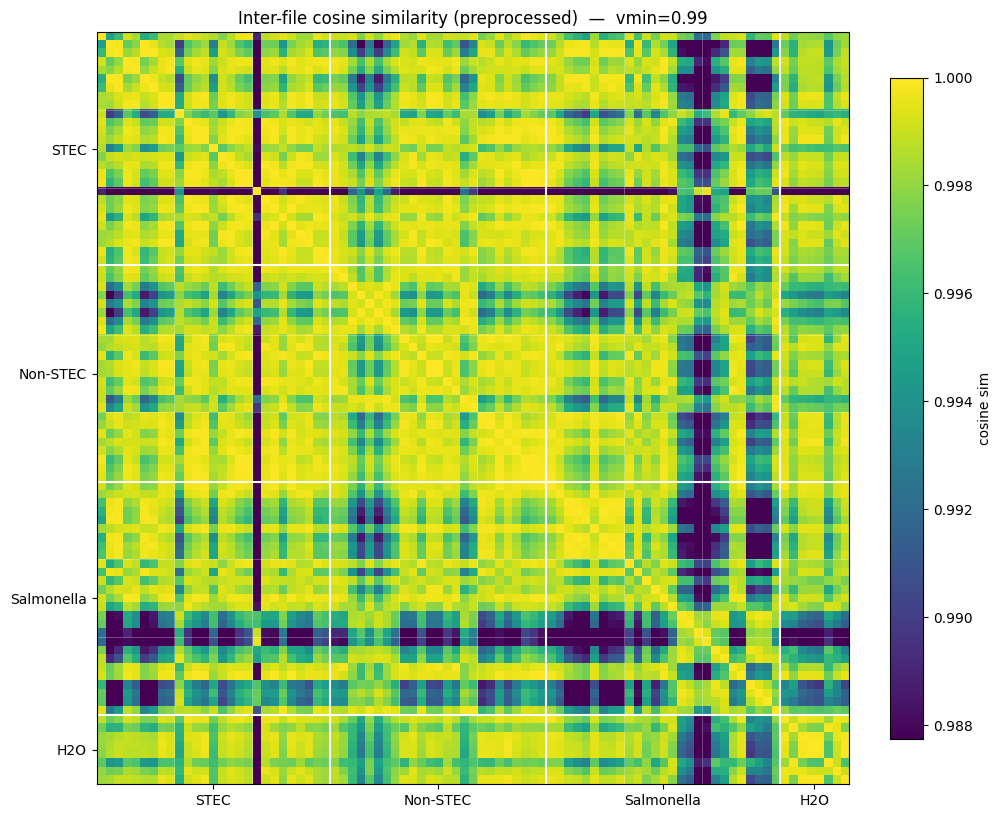

In [10]:
from sklearn.metrics.pairwise import cosine_similarity

file_means = []
file_ids_sorted = []
file_labels = []
for fid, g in spec_df.groupby("file_id", sort=False):
    file_ids_sorted.append(fid)
    file_means.append(X_proc[g.index.to_numpy()].mean(0))
    pc = g["primary_class"].iloc[0]
    sc = g["subclass"].iloc[0]
    file_labels.append((pc, sc if isinstance(sc, str) else "—"))

file_means = np.asarray(file_means)
order = sorted(range(len(file_ids_sorted)),
               key=lambda i: (CLASS_ORDER.index(file_labels[i][0]),
                              file_labels[i][1], file_ids_sorted[i]))
fm_s = file_means[order]
labels_s = [file_labels[i] for i in order]

S = cosine_similarity(fm_s)
vmin = float(np.percentile(S, 5))

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(S, cmap="viridis", vmin=vmin, vmax=1)
ax.set_title(f"Inter-file cosine similarity (preprocessed)  —  vmin={vmin:.2f}")

class_boundaries = []
prev = None
for i, (pc, _) in enumerate(labels_s):
    if pc != prev:
        class_boundaries.append((i, pc))
        prev = pc
for b, _ in class_boundaries[1:]:
    ax.axhline(b - 0.5, color="white", lw=1.5)
    ax.axvline(b - 0.5, color="white", lw=1.5)
prev = None
for i, (pc, sc) in enumerate(labels_s):
    key = (pc, sc)
    if key != prev:
        ax.axhline(i - 0.5, color="white", lw=0.4, alpha=0.5)
        ax.axvline(i - 0.5, color="white", lw=0.4, alpha=0.5)
        prev = key

tick_pos, tick_lbl = [], []
for b, pc in class_boundaries:
    end = next((bb for bb, _ in class_boundaries[class_boundaries.index((b, pc)) + 1:]),
               len(labels_s))
    tick_pos.append((b + end) / 2 - 0.5)
    tick_lbl.append(pc)
ax.set_xticks(tick_pos); ax.set_xticklabels(tick_lbl)
ax.set_yticks(tick_pos); ax.set_yticklabels(tick_lbl)
plt.colorbar(im, ax=ax, fraction=0.04, label="cosine sim")
plt.tight_layout()
plt.savefig(SUMMARY / "06_interfile_similarity.png", bbox_inches="tight")
plt.show()


## Done

All plots saved under `images/`:

```
images/
  _summary/                  ← 6 dataset-level plots
  H20/
    R372_100_10000ms_260306/
      01_overlay.png
      02_heatmap.png
      03_spatial.png
      04_mean_band.png
    ...
  Non STEC/
    83972/
      R475_100_10000ms_260317/
        ...
    ATCC25922/...
    K-12/...
  Salmonella/
    Dublin/...
    Heidelburg/...
    Typhimurium/...
  STEC/
    O103H2/...
    O121H19/...
    O157H7/...
```
